# PRFPY Visualization guide 
This is a guide for showing you how to plot the pRF fits produced by prfpy. This include:

- Timeseries data
- Basic sanity checks
- Plotting on the cortical surface (in line, python)
- Opening plots in freesurfer

In [42]:
# Import relevant tools
# - select "prf" conda environment for your kernel
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel, Norm_Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter, Norm_Iso2DGaussianFitter
from prfpy.rf import gauss2D_iso_cart

import os
opj = os.path.join
import yaml
import pickle
from datetime import datetime

import glob
import re
import shutil
from pathlib import Path
import yaml

# Mesh plotting & ROI integration
from dpu_mini.mesh_maker import *
from dpu_mini.fs_tools import *

# PRFPY plotting 
from dpu_mini.plot_functions import *
from cvl_utils.prf_utils import *
from cvl_utils.prfpy_utils import *
from cvl_utils.prfpy_plotter import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First we set the following:
- subject; session; task
- where we got the timeseries
- where we put the fits

Then everything relevant is loaded from that




In [43]:
subject = 'sub-hp01'
session = 'ses-01'
task = 'pRFLE'

ts_file = 's4_conf_sgw-347_po-3_d-0_pca6_PreRefactor'
prf_file = 's5_prf_testing'


# ---- ---- ---- ---- ---- ---- ---- ----
from s01_gauss_prfpy import _get_dm_and_settings

bids_dir = os.environ['BIDS_DIR']
project = os.environ['PROJ_NAME']
fsdir = opj(bids_dir, 'derivatives', 'freesurfer')
ts_dir = opj(bids_dir, 'derivatives', ts_file)
prf_dir = opj(bids_dir, 'derivatives', prf_file)
sub_ts_dir = opj(ts_dir, subject, session)
sub_prf_dir = opj(prf_dir, subject, session)

gm = GenMeshMaker(subject, fsdir)

# Load parameters fit
grid_csv = glob.glob(opj(sub_prf_dir, f'*{task}*grid.csv'))
iter_csv = glob.glob(opj(sub_prf_dir, f'*{task}*iter.csv'))
if iter_csv==[]:
    if len(grid_csv)==1:
        prf_pd = pd.read_csv(grid_csv[0])
else:
    if len(iter_csv)==1:
        prf_pd = pd.read_csv(iter_csv[0])

# Load settings 
prf_settings, dm = _get_dm_and_settings(task, project) 
psc_ts_file = glob.glob(opj(sub_ts_dir, f'*{task}*.npy'))[0]
# select only that part of the timeseries we used during fitting
# -> the index in .csv tells us which vertices were fit

roi_bool = np.zeros(gm.total_n_vx, dtype=bool)
roi_bool[prf_pd['index']] = True
# -> the vols_to_chop, tells us which volumes were excluded
psc_ts = np.load(
    psc_ts_file
    )[roi_bool,prf_settings['vols_to_chop']:]  

# Load the parameters + time series + model object 
prf_stim = PRFStimulus2D(
    screen_size_cm=prf_settings['screen_size_cm'],          # Distance of screen to eye
    screen_distance_cm=prf_settings['screen_distance_cm'],  # height of the screen (i.e., the diameter of the stimulated region)
    design_matrix=dm,                                   # dm (npix x npix x time_points)
    TR=prf_settings['TR'],                                  # TR
    )
print(f'Screen size in degrees of visual angle = {prf_stim.screen_size_degrees}')
gmodel = Iso2DGaussianModel(
    stimulus=prf_stim,                                  # The stimulus we made earlier
    hrf=prf_settings['hrf']['pars'],                        # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
    filter_predictions = prf_settings['filter_predictions'],# Do you want to filter the predictions? (depends what you did to the data, try and match it... default is not to do anything)
    normalize_RFs= prf_settings['normalize_RFs'],           # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
    # FILTER SETTINGS TO DO
    )
prf_np = pd_to_np(prf_pd, 'gauss')
po = TSPlotter(
    prf_np, 
    model='gauss', 
    prfpy_model=gmodel,
    real_ts=psc_ts
)



Using fs dir = /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/freesurfer
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Screen size in degrees of visual angle = 43.311978076844994
prf_params.shape[-1]=8
include hrf = True
include rsq = True


Intro to "po"

In [44]:
# The prfpy plotting stuff I have put together is here just to make your life easier
# I have a bunch of pre built functions for plotting etc. 
# but if you prefer to just do it yourself just use the outputs of the fitter
# & you are good to go
prf_pd

,Unnamed: 0,index,mu_x,mu_y,size,beta,baseline,hrf_1,hrf_2,rsq
0,0,0,2.880113,-2.416702,0.866240,0.187437,-0.794663,1.0,0.0,0.558259
1,1,2,1.843272,-1.546689,0.216560,1.349623,-0.391113,1.0,0.0,0.428370
2,2,5,1.843272,-1.546689,0.216560,1.368497,-0.368536,1.0,0.0,0.418782
3,3,6,1.843272,-1.546689,0.216560,2.370964,-0.672226,1.0,0.0,0.548236
4,4,9,1.843272,-1.546689,0.216560,1.368497,-0.368536,1.0,0.0,0.418782
...,...,...,...,...,...,...,...,...,...,...
7749,7749,277513,2.115294,-11.996430,1.949039,0.033363,-1.173320,1.0,0.0,0.531218
7750,7750,277531,-3.532981,1.285900,0.866240,0.047663,-0.032747,1.0,0.0,0.123337
7751,7751,277539,21.655989,0.000000,0.216560,0.476998,0.076212,1.0,0.0,0.016339
7752,7752,277626,-11.446860,4.166316,3.464958,0.004170,-0.368458,1.0,0.0,0.124758


## [1] Plotting time series

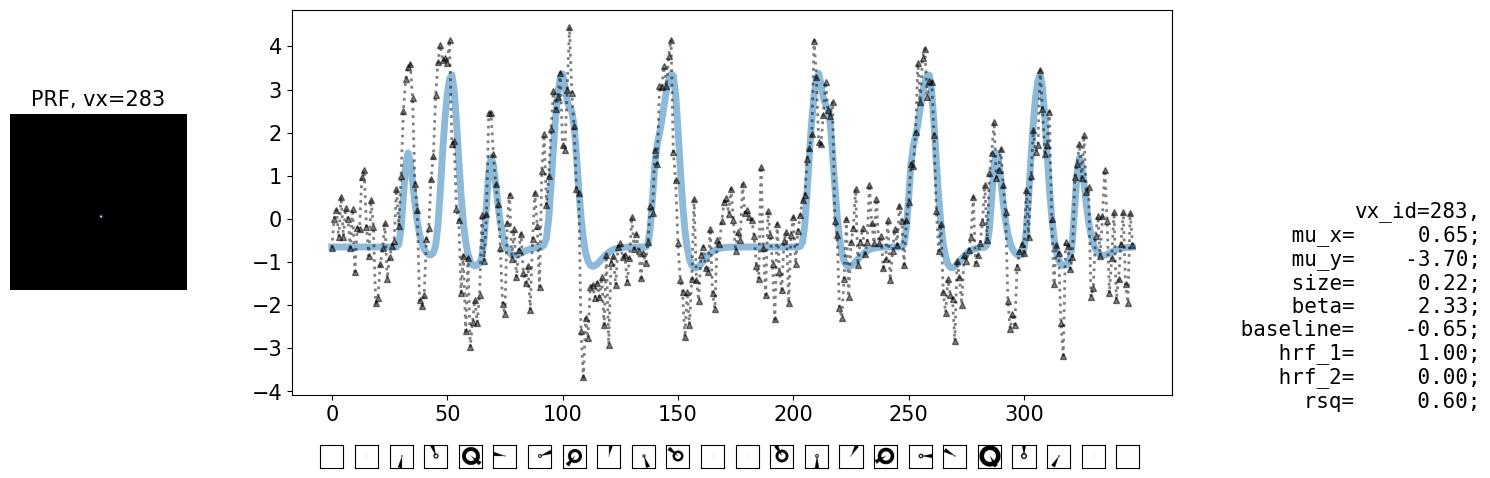

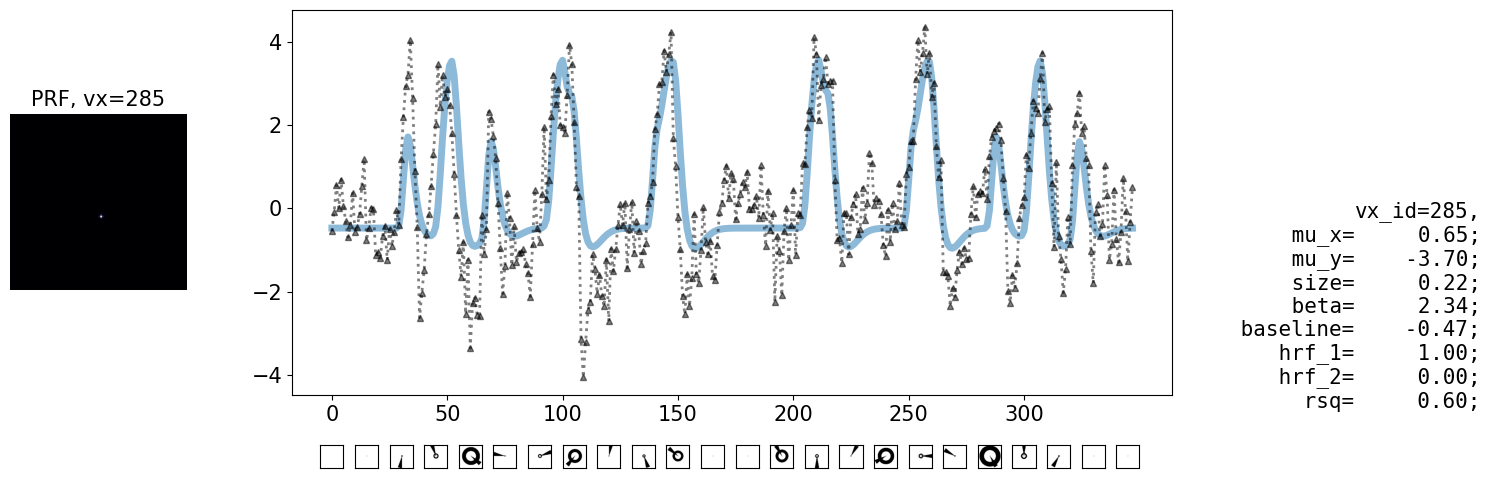

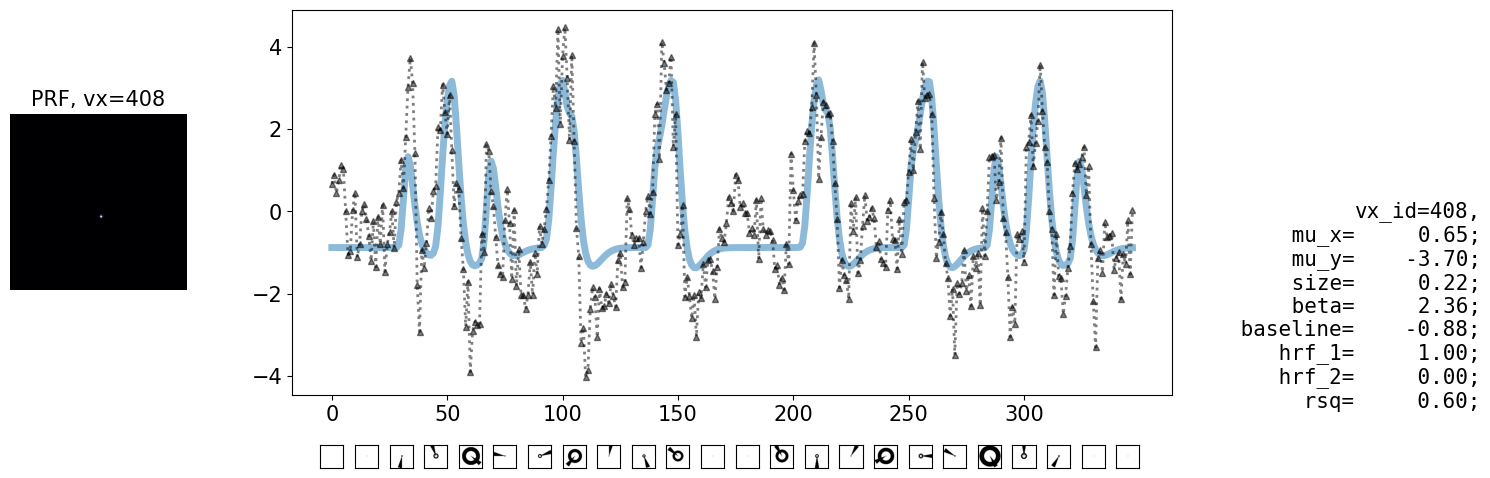

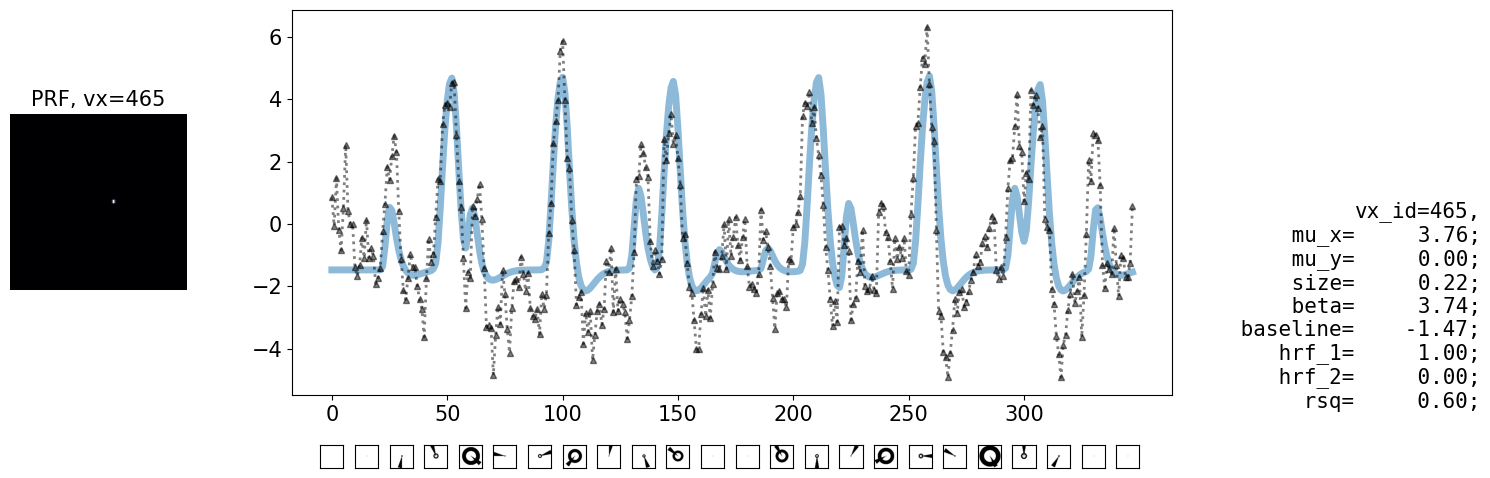

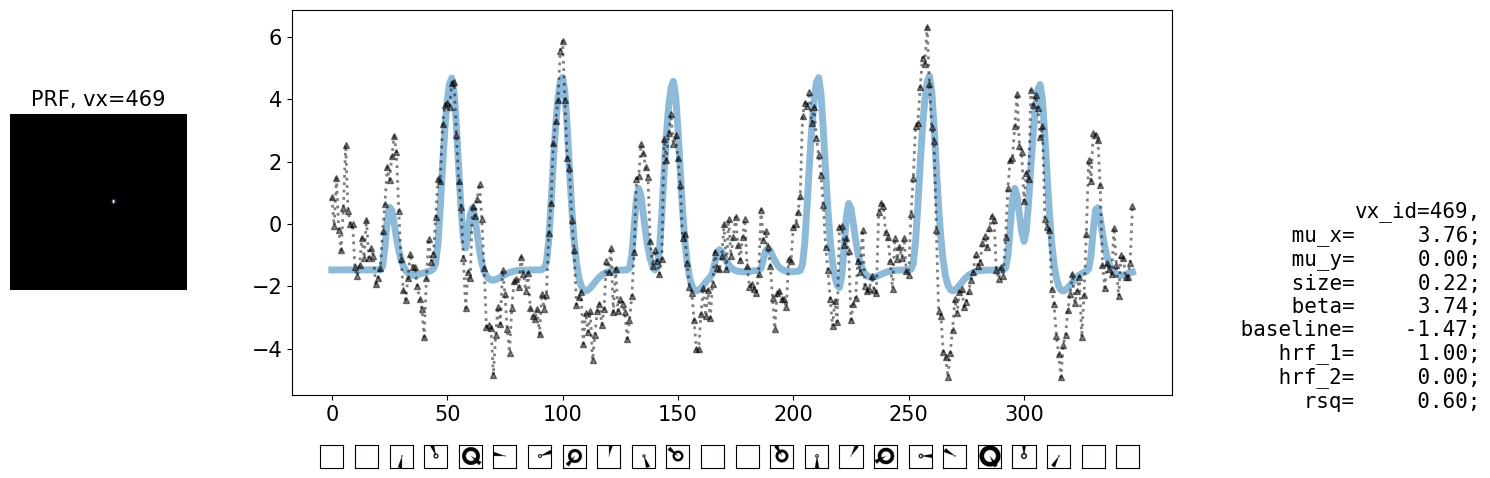

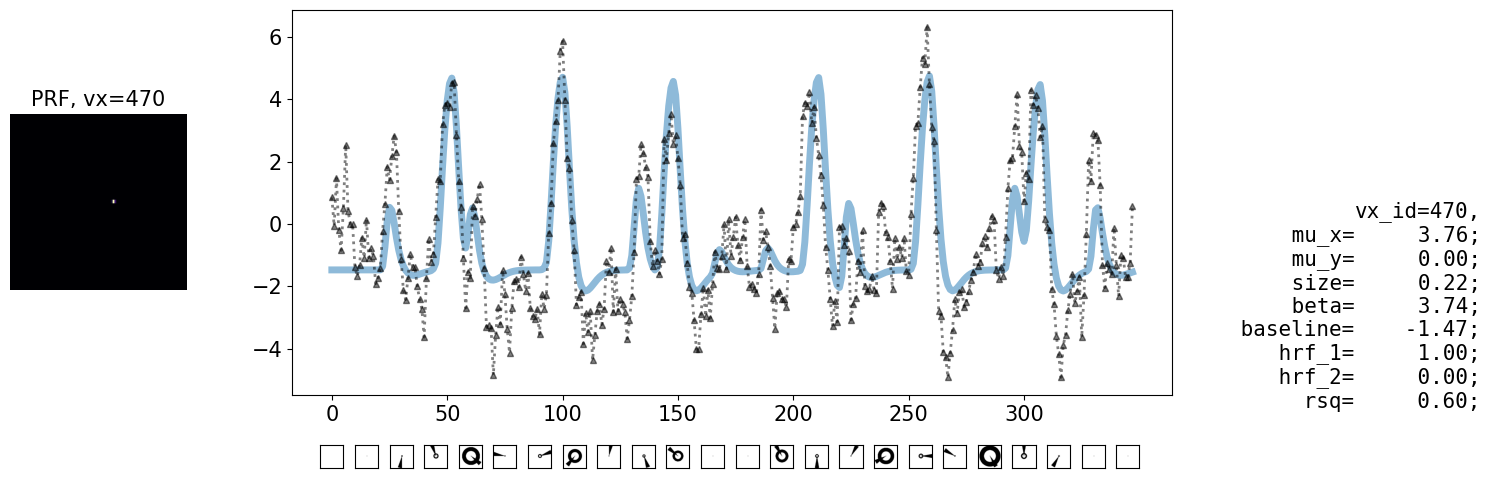

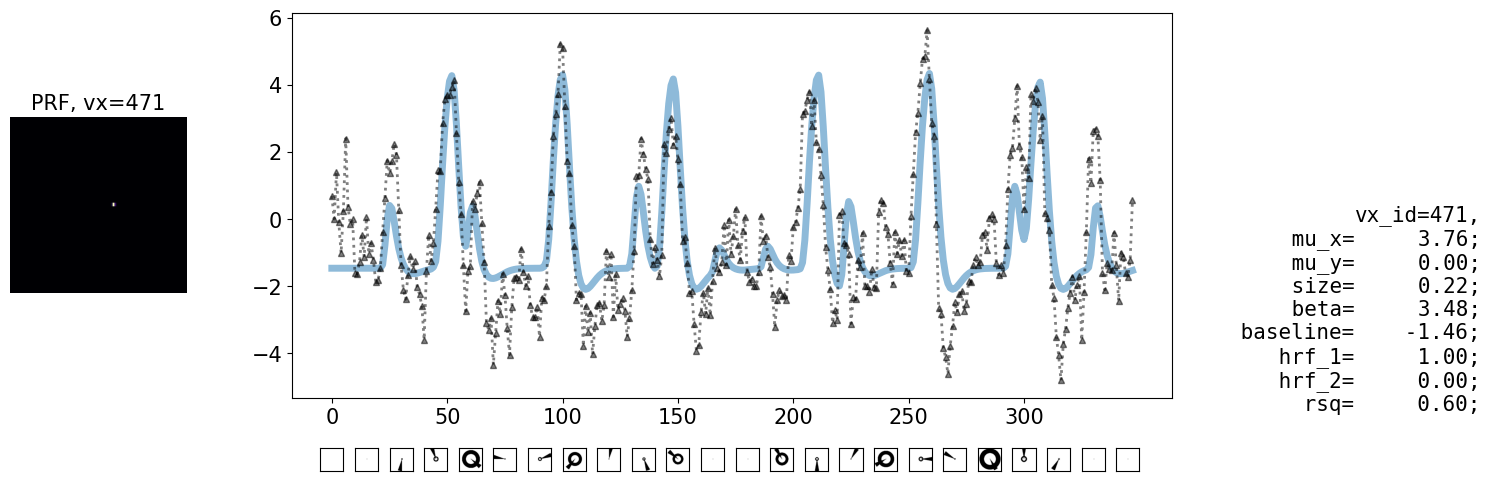

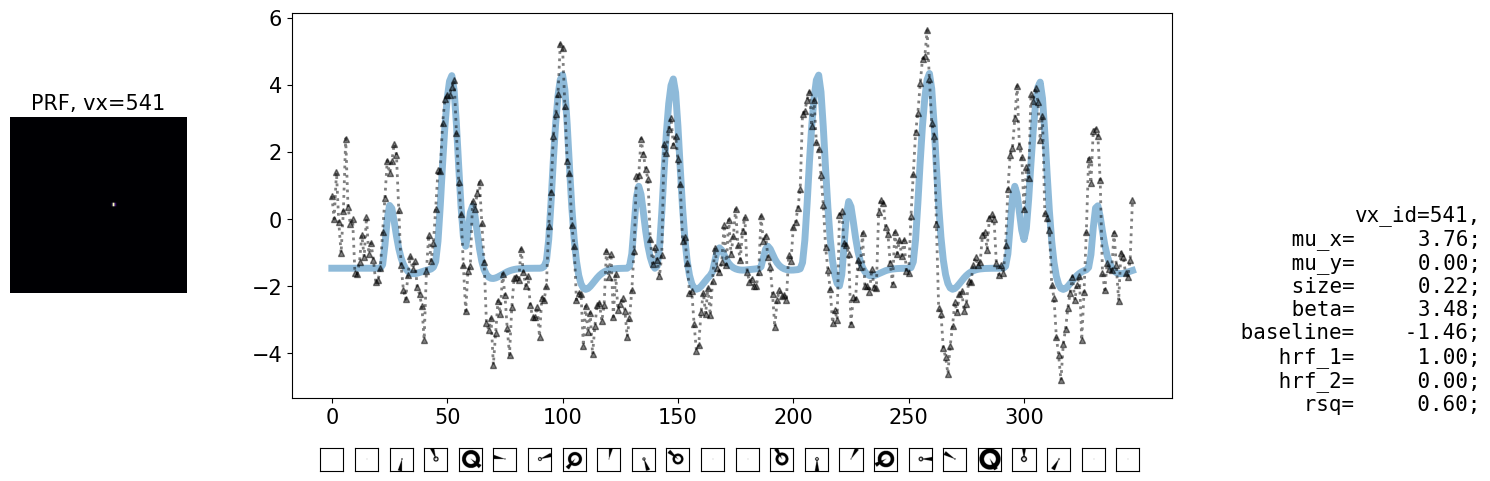

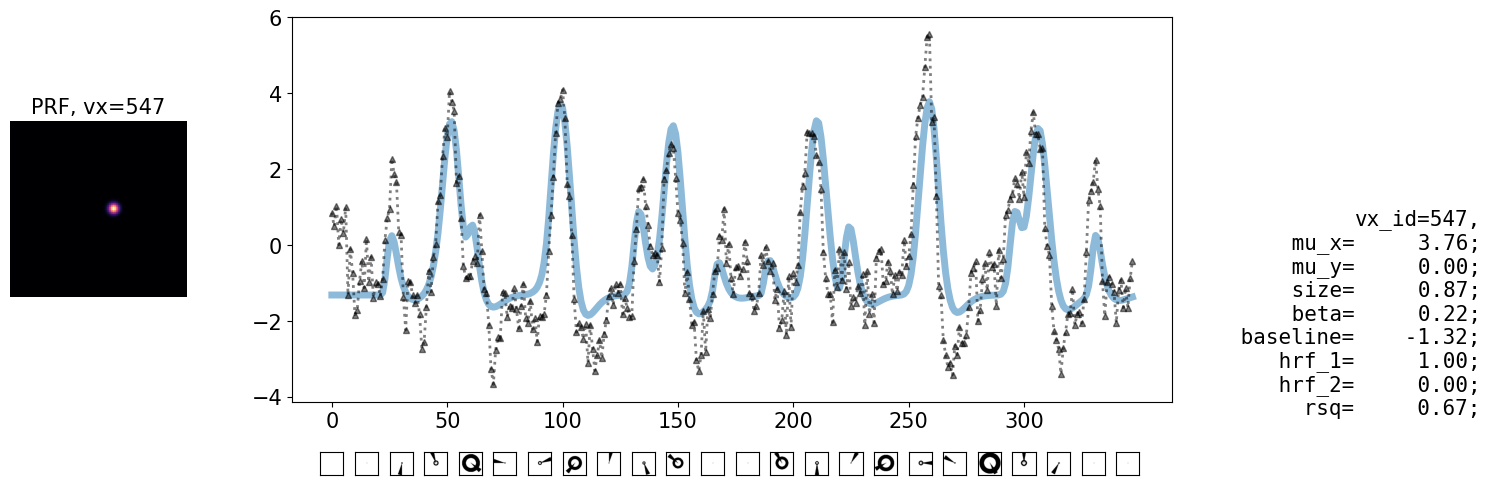

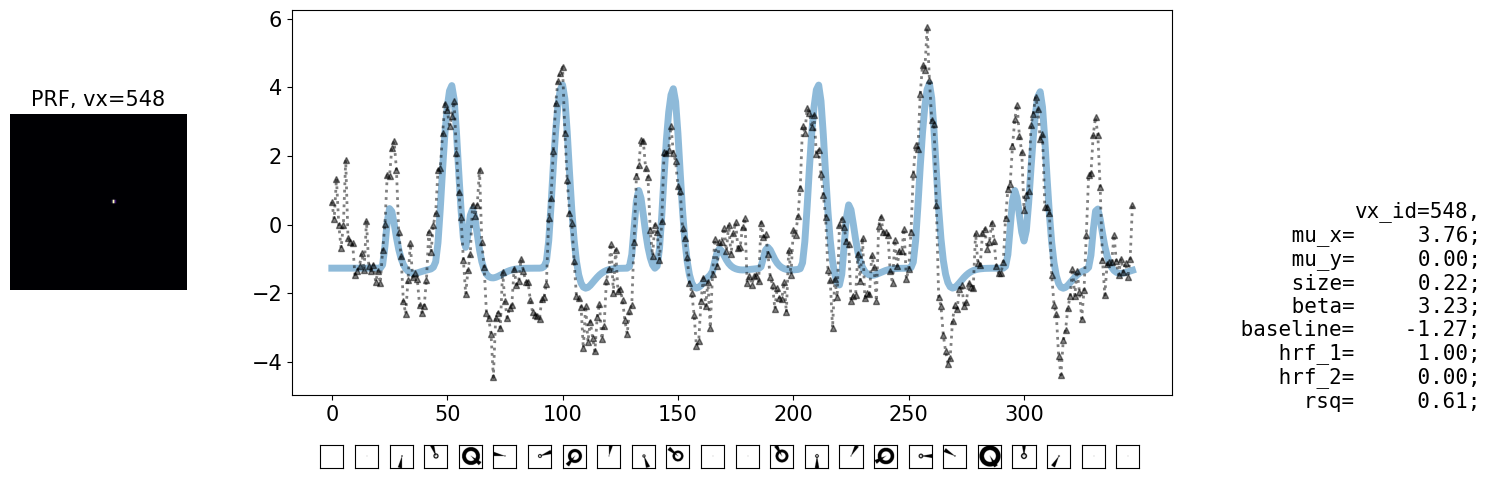

In [10]:
# First lets find some really good pRFs (high variance explained - r2)
good_vx = np.where(po.pd_params['rsq']>0.6)[0]

# lets plot 10 of them to get a feel for the data...
# use the "po" (prf object) we created earlier to do some plotting
for idx in good_vx[:10]:
    _ = po.prf_ts_plot(idx=idx, do_dm=True) # do_dm=True to plot the design matrix underneath the timeseries


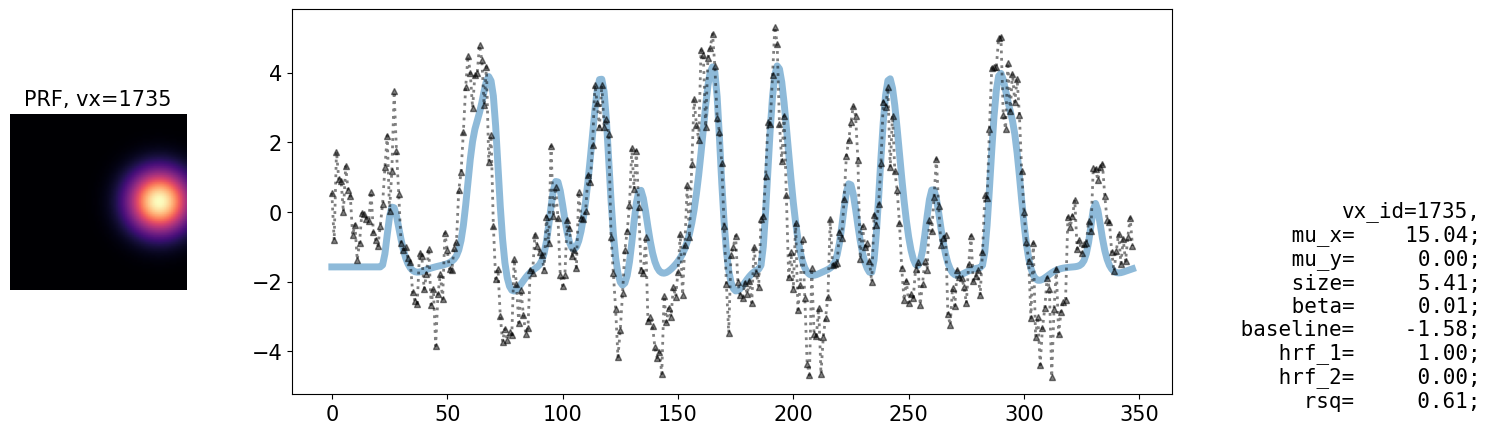

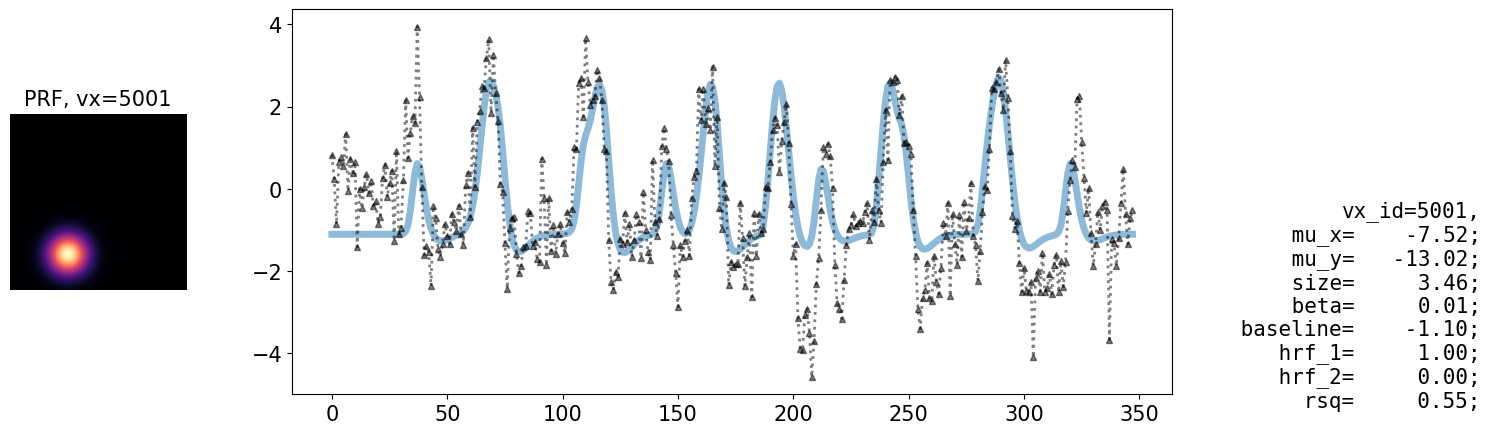

In [11]:
# Experiment, look at different timeseries - they should make sense! (i.e., match the data)
# Look at the location of the prf in the visual field on the right as well

# Lets find a good vx with a big pRF ...
big_good = np.where(
    (po.pd_params['rsq']>0.6) & (po.pd_params['size']>5.0)
    )[0][0]
_ = po.prf_ts_plot(big_good)

# on the bottom left quadrant...
edge_good = np.where(
    (po.pd_params['rsq']>0.5) & \
        (po.pd_params['mu_x']<-7.0) & \
        (po.pd_params['mu_y']<-7.0)
    )[0][0]
_ = po.prf_ts_plot(edge_good)
# ... you get the idea


*helpful tip* - you should alway always spend some time playing around plotting different vertices at this stage. You may notice something off, maybe the is defined weirdly, maybe your stimulus timing is off (are the bumps in the data always ahead/behind the bumps in the predictions). Are you getting weird bunching of pRFs in around the middle? These are all things you can only get by looking at the data, again and again. 

I have helped out several groups with pRF mapping over the years, and it is very common that people miss little details. Often it won't matter - but it might :) 


Sit down, with a coffee and some music, click through. You won't know what you are looking at to begin with, but very quickly you will begin to spot patterns etc. This instinct is super helpful for understanding and getting these things as precise and accurate as possible 

## [2] Plotting - sanity checks

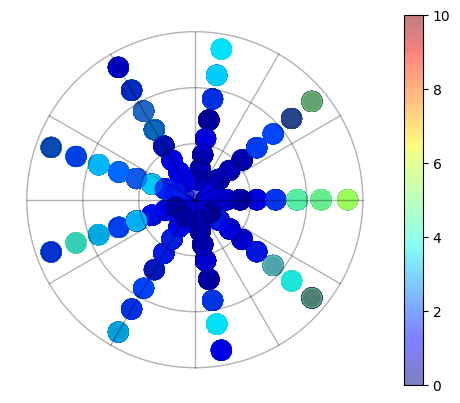

In [45]:
# Have a look around the visual field
# -> are there a bunch of pRFs stuck in the middle? Has something gone wrong? 
po.visual_field(
    # set a threshold:
    th={
        'min-rsq': 0.1, 
        'max-ecc': 20, 
    }, 
    dot_col='size', # set dot colour based on size of the pRF
    dot_cmap='jet', dot_vmin=0, dot_vmax=10.0, 
    ecc_bounds=np.linspace(0, 20, 4),
)

/Users/marcusdaghlian/programs/dpu_mini/dpu_mini/plot_functions.py:711: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


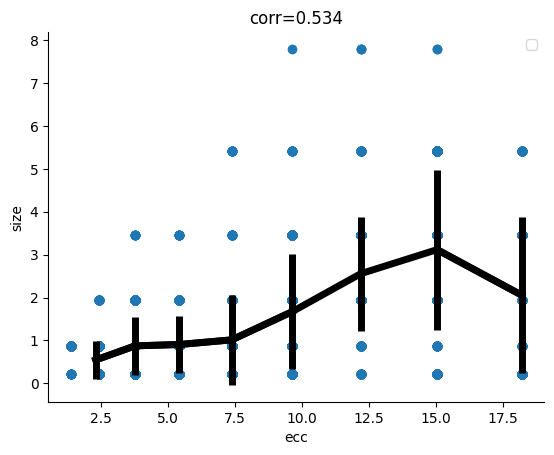

In [17]:
# Size vs eccentricity 
# -> the most replicable finding in pRFs: they get bigger, as eccentricity goes up

po.scatter(
    px = 'ecc', # eccentricity on the x axis
    py = 'size', # size on the y axis, 
    # set a threshold:
    th={
        'min-rsq': 0.1, # variance explained greater than 0.1
        'max-ecc': 20,  # Only pRFs with centres inside the stimulated region
    }, 
    do_corr=True, # print the correlation, should be +ve (if healthy controls)
    do_line=True, 
    # dot_col='size', # set dot colour based on size of the pRF
    # dot_cmap='jet', dot_vmin=0, dot_vmax=10.0 
)

# [3] Plotting on the surface
I built a repository for quickly plotting properties on the cortical surface (dpu_mini). It takes the surfaces from freesurfer. 

Faces with missing vx: 258814
Faces with long edges: 0
0.07053897204585284
Faces with missing vx: 259401
Faces with long edges: 0
0.06339228330649413
Just using undersurface file..


{'cmap': 'viridis', 'vmin': np.float64(0.0), 'vmax': np.float64(0.0)}

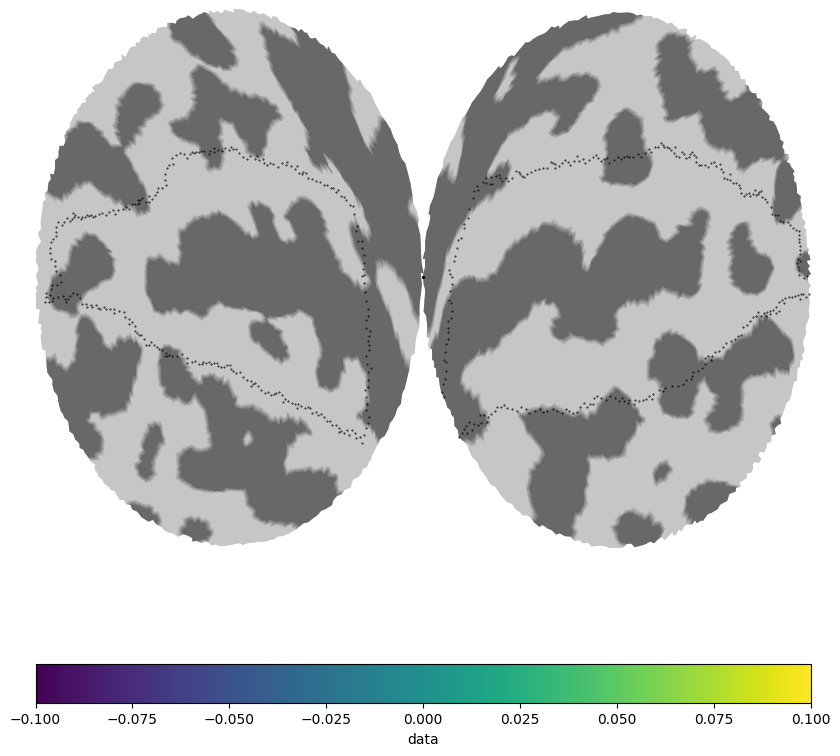

In [41]:
# My code for plotting pRFs on the cortical surface
# -> make a flat map for the area we fit
# -> can try different levels of "zoom"
# 0 -> 1 (0=not very zoomed; 1=100% zoomed) I recommend 0.9
gm.make_flat_map(roi_bool, cut_circle=0.9) # 0.9 is very zoomed to our ROI
gm.flat_mpl(roi_list='b14_V1.', )


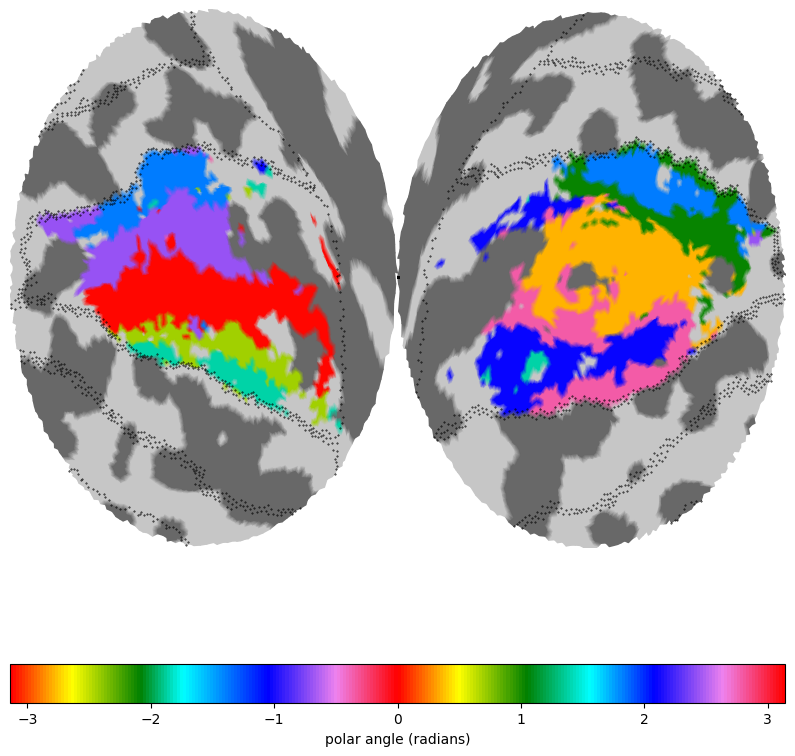

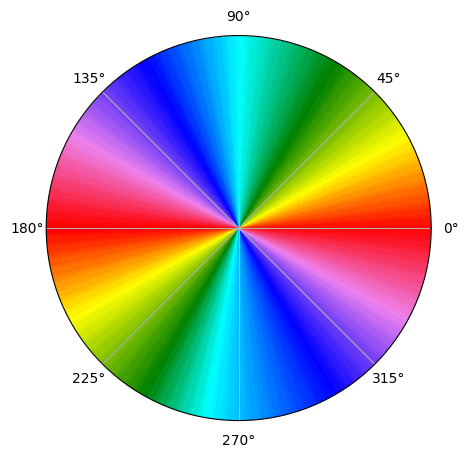

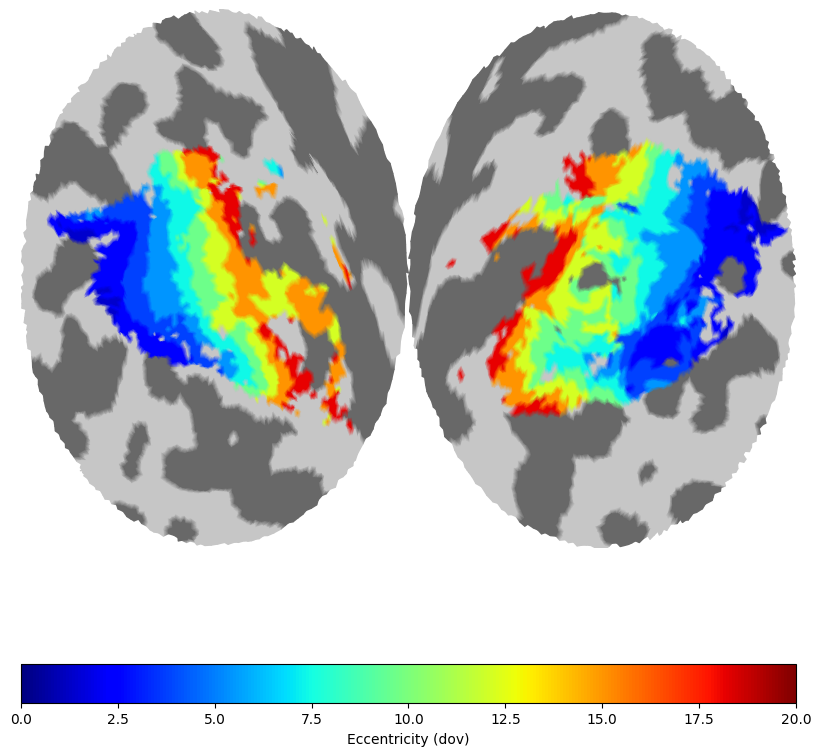

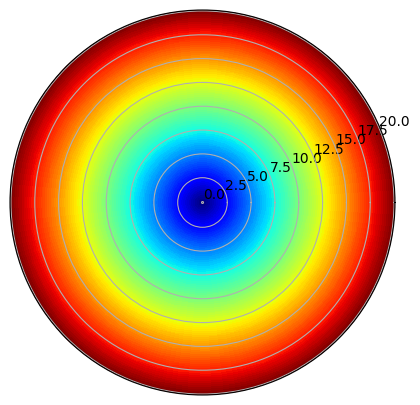

In [22]:
# Now lets plot the important prf properties
# -> only those vx we are interested in (high Rsq, inside the screen)
prf_mask = po.return_vx_mask(th={'min-rsq':0.1, 'max-ecc':20})

# Polar angle
gm.flat_mpl(
    data=po.pd_params['pol'], 
    data_sub_mask=roi_bool, # Which vertices does "data" point to 
    data_mask = prf_mask,   # Of those vertices, which do we want to show?
    cmap='marco_pol',       # Colour map (my personal favourite, custom made)
    vmin=-np.pi, vmax=np.pi, # Range of values (polar angles are in radians)
    surf_name='polar angle (radians)', 
    roi_list=['b14_V1.', 'b14_V2.', 'b14_V3.'] # List of freesurfer rois to show
)
dpu_cmap_plotter(
    'marco_pol', plot_type='pol',
    vmin=-np.pi, vmax=np.pi

)
# Eccentricity 
# Polar angle
gm.flat_mpl(
    data=po.pd_params['ecc'], 
    data_sub_mask=roi_bool,
    data_mask = prf_mask,
    cmap='jet',       
    vmin=0, vmax=20, 
    surf_name='Eccentricity (dov)',
    plot_type='ecc'
)
dpu_cmap_plotter(
    'jet', plot_type='ecc', 
    vmin=0, vmax=20, 
)


{'cmap': 'plasma', 'vmin': 0, 'vmax': 1}

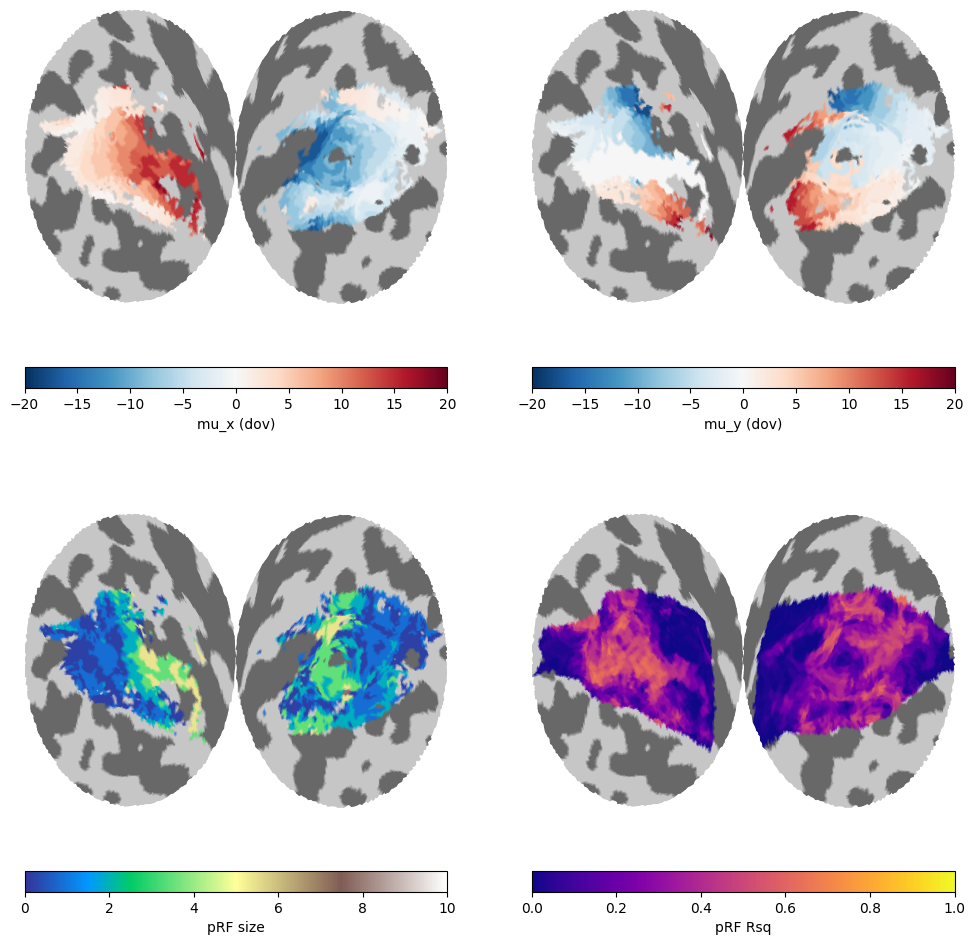

In [37]:
# Other properties:
fig, axs = plt.subplots(2,2, figsize=(12,12))
axs = axs.flatten()
axidx = 0

# x,y
for p in ['mu_x', 'mu_y']:
    # Is negative x in the right hemisphere? (& +ve x in the left)
    # Is upper visual field represented in ventral part
    gm.flat_mpl(
        data=po.pd_params[p], 
        data_sub_mask=roi_bool,
        data_mask = prf_mask,
        cmap='RdBu_r',       
        vmin=-20, vmax=20, 
        surf_name=f'{p} (dov)',
        ax=axs[axidx], 
    )
    axidx += 1

# Size
gm.flat_mpl(
    data=po.pd_params['size'], 
    data_sub_mask=roi_bool,
    data_mask = prf_mask,
    cmap='terrain',       
    vmin=0, vmax=10, 
    surf_name=f'pRF size',
    ax=axs[axidx], 
)
axidx += 1


# Size
gm.flat_mpl(
    data=po.pd_params['rsq'], 
    data_sub_mask=roi_bool,
    data_alpha=np.ones_like(po.pd_params['rsq']),
    cmap='plasma',       
    vmin=0, vmax=1, 
    surf_name=f'pRF Rsq',
    ax=axs[axidx], 
)


# DONE!